<a href="https://colab.research.google.com/github/liangliang6v6/Homeworks/blob/pages/Homework5_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Task 2 (15 points):
###Part 1 (7 points):
Variational Autoencoder (VAE): Here is a complete implementation of
a VAE in TensorFlow: https://www.tensorflow.org/tutorials/generative/cvae
PyTorch implementation is fine too.
Following these steps try generating images using the same encoder-decoder
architecture using a different Image dataset (other than MNIST).

In [4]:
!pip3 install torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 105.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 86.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [1]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10

# the transformation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# use CIFAR 10 as the dataset
train_dataset = CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

100%|██████████| 170M/170M [00:04<00:00, 40.7MB/s]


In [2]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),  # (16, 16)
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),  # (8, 8)
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),  # (4, 4)
            nn.ReLU(),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(128 * 4 * 4, 128)
        self.fc_logvar = nn.Linear(128 * 4 * 4, 128)
        self.fc_dec = nn.Linear(128, 128 * 4 * 4)

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # (8, 8)
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # (16, 16)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),  # (32, 32)
            nn.Tanh()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        z = self.reparameterize(mu, logvar)
        z = self.fc_dec(z).view(-1, 128, 4, 4)
        return self.decoder(z), mu, logvar

In [6]:
def loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.mse_loss(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

# use GPU to train
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

def train():
    vae.train()
    train_loss = 0
    for data, _ in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = vae(data)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
    print(f"Train Loss: {train_loss / len(train_loader.dataset)}")

for epoch in range(1, 11):
    print(f"Epoch {epoch}:")
    train()


Epoch 1:
Train Loss: 328.8723169140625
Epoch 2:
Train Loss: 220.7325663671875
Epoch 3:
Train Loss: 205.4260064453125
Epoch 4:
Train Loss: 199.212491015625
Epoch 5:
Train Loss: 195.53812845703126
Epoch 6:
Train Loss: 193.1470493359375
Epoch 7:
Train Loss: 191.38155966796876
Epoch 8:
Train Loss: 190.20063865234374
Epoch 9:
Train Loss: 189.2084598046875
Epoch 10:
Train Loss: 188.382941875


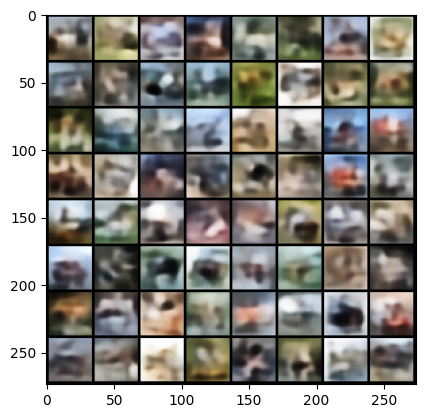

In [7]:
import torchvision

import matplotlib.pyplot as plt

vae.eval()
with torch.no_grad():
    z = torch.randn(64, 128).to(device)
    sample = vae.decoder(vae.fc_dec(z).view(-1, 128, 4, 4)).cpu()
    sample = sample * 0.5 + 0.5  # unnormalize
    grid_img = torchvision.utils.make_grid(sample, nrow=8)
    plt.imshow(grid_img.permute(1, 2, 0))
    plt.show()

###Part 2 (8 points):
Generative Adversarial Networks (GANs): Repeat part 1 (use same
dataset) and implement a GAN model to generate high quality synthetic images. You may follow the steps outlined here: https://www.tensorflow.org/tutorials/generative/dcgan

In [8]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, 3 * 32 * 32),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x).view(-1, 3, 32, 32)


class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Linear(3 * 32 * 32, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x.view(-1, 3 * 32 * 32))

In [9]:
# prepare model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = Generator().to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()
optimizer_g = optim.Adam(generator.parameters(), lr=0.0002)
optimizer_d = optim.Adam(discriminator.parameters(), lr=0.0002)

In [10]:
import numpy as np

def train_gan(epochs):
    for epoch in range(epochs):
        for i, (real_images, _) in enumerate(train_loader):
            batch_size = real_images.size(0)
            real_images = real_images.to(device)
            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)

            # Train Discriminator
            optimizer_d.zero_grad()
            outputs = discriminator(real_images)
            real_loss = criterion(outputs, real_labels)
            real_loss.backward()

            z = torch.randn(batch_size, 100).to(device)
            fake_images = generator(z)
            outputs = discriminator(fake_images.detach())
            fake_loss = criterion(outputs, fake_labels)
            fake_loss.backward()
            optimizer_d.step()

            d_loss = real_loss + fake_loss

            # Train Generator
            optimizer_g.zero_grad()
            z = torch.randn(batch_size, 100).to(device)
            fake_images = generator(z)
            outputs = discriminator(fake_images)
            g_loss = criterion(outputs, real_labels)
            g_loss.backward()
            optimizer_g.step()

        print(f'Epoch [{epoch+1}/{epochs}], d_loss: {d_loss.item()}, g_loss: {g_loss.item()}')

train_gan(epochs=50)

Epoch [1/50], d_loss: 0.04894396662712097, g_loss: 4.324626922607422
Epoch [2/50], d_loss: 0.7435232996940613, g_loss: 28.21518325805664
Epoch [3/50], d_loss: 0.11562708020210266, g_loss: 4.317216873168945
Epoch [4/50], d_loss: 0.14889845252037048, g_loss: 4.825618267059326
Epoch [5/50], d_loss: 0.5453780293464661, g_loss: 7.403601169586182
Epoch [6/50], d_loss: 0.38838380575180054, g_loss: 2.3234612941741943
Epoch [7/50], d_loss: 0.36616677045822144, g_loss: 2.9241623878479004
Epoch [8/50], d_loss: 0.33619818091392517, g_loss: 4.3869948387146
Epoch [9/50], d_loss: 0.2369798868894577, g_loss: 8.06910228729248
Epoch [10/50], d_loss: 0.11901238560676575, g_loss: 5.0009565353393555
Epoch [11/50], d_loss: 0.23264193534851074, g_loss: 4.0757670402526855
Epoch [12/50], d_loss: 0.07859878242015839, g_loss: 7.2121429443359375
Epoch [13/50], d_loss: 0.09352369606494904, g_loss: 5.217728614807129
Epoch [14/50], d_loss: 0.1782829463481903, g_loss: 4.7984843254089355
Epoch [15/50], d_loss: 0.34349

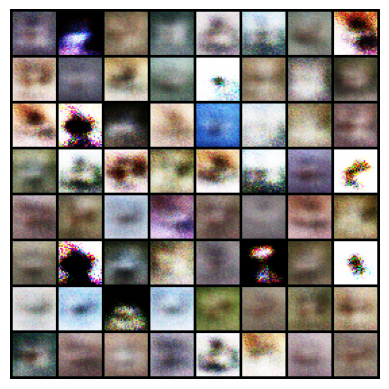

In [11]:
import torchvision
import matplotlib.pyplot as plt

def generate_images():
    generator.eval()
    with torch.no_grad():
        z = torch.randn(64, 100).to(device)
        fake_images = generator(z).cpu()
        fake_images = (fake_images + 1) / 2  # Unnormalize
        grid = torchvision.utils.make_grid(fake_images, nrow=8, padding=2)
        plt.imshow(grid.permute(1, 2, 0).numpy())
        plt.axis('off')
        plt.show()

generate_images()